In [ ]:
import muspan as ms
import matplotlib.pyplot as plt
import numpy as np
import cv2
import matplotlib.cm as cm

from persim import plot_diagrams

print("Packages loaded successfully!")

Packages loaded successfully!


In [3]:
def cycle_intensity(cycles):
    #cycle strength is cycle death time
    cycles = [i[1] for i in cycles]
    return cycles

def edge_strength(components,b1=5,b2=100,plot=False):
    #edge strength is component birth time
    edges = [i[0] for i in components]
    return edges

def component_intensity(components,d1=150,plot=False):
    #component intensity is component death time
    components = [i[1] for i in components]
    return components

def hole_strength(cycles):
    #hole strength is cycle birth time
    cycles = [i[0] for i in cycles]
    return cycles

In [4]:
def basic_filtering(components,cycles, min_lifespan=30,upper=200,plot=False):

    print(f"Number of components before: {len(components)}")
    comp_filter = [i[1]-i[0]>=min_lifespan for i in components] #filter min lifespan
    comp_filter2 = [i[0]<=upper for i in components] #filter below birth limit
    components = components[np.logical_and(comp_filter,comp_filter2)]

    print(f"Number of components after filtering: {len(components)}")


    print(f"Number of cycles before: {len(cycles)}")
    cycle_filter = [i[1]-i[0]>=min_lifespan for i in cycles] #filter min lifespan
    cycle_filter2 = [i[0]<=upper for i in cycles] #filter below birth limit
    cycles = cycles[np.logical_and(cycle_filter,cycle_filter2)]
    print(f"Number of cycles after filtering: {len(cycles)}")

    if plot:
        plot_diagrams([components,cycles], show=True)
    return([components,cycles])

Image is 500 wide and 508 tall
Number of components before: 29
Number of components after filtering: 13
Number of cycles before: 17
Number of cycles after filtering: 3


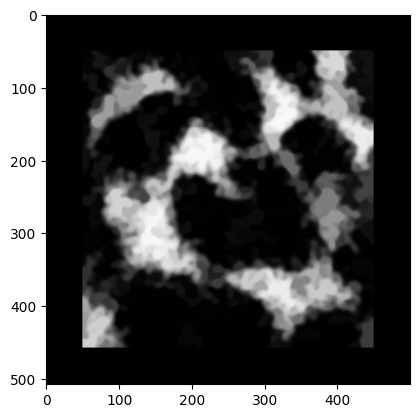

In [5]:
path = f"data/PH_histograms/test"
stages = [3,4,5,6,8,9,10,11,12]
new_width = 500

image = cv2.imread(f'{path}/hh6_flattened_blur_threshold_stack_min_size_reconstructed_border.png') #test image
#image = cv2.imread(f'data/PH scaled/{n}/hh{stage}BCblur.png')
background_colour = "black"

height = len(image)
width = len(image[0])

new_height = int(new_width/width * height)
plt.imshow(image)
image = cv2.resize(image, (new_width,new_height)) #downscale to not crash python
if background_colour == "white": #invert image so we can filter in right direction (PH filters from black to white)
    image = 255-image

grey_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print(f"Image is {len(image[0])} wide and {len(image)} tall")

#run PH
result = ms.topology.level_set_filtration(grey_image) 


cycles = result["dgms"][0] #reverse the cycle and components (because we filtered black to white instead of white to black: hacky workaround)
components = result["dgms"][1]

cycles = cycles[[ r[1]<999 for r in cycles]] #remove the infinite cycle generated
#print(components)
#print("\n")
#print(cycles)



#plot_diagrams([components, cycles], show=True)
# plot_diagrams([cycles], show=True)

#apply filtering or not
[components,cycles] = basic_filtering(components,cycles,min_lifespan=10)

filtered_persistence = {"dgms":[components,cycles]}


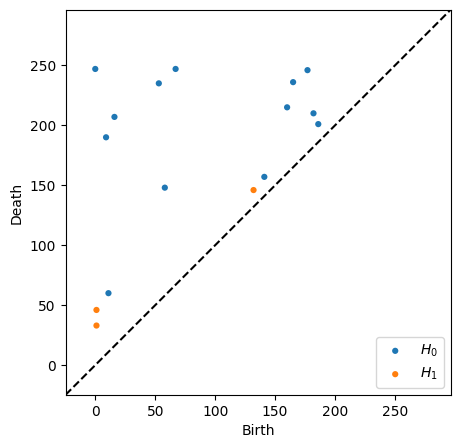

In [6]:
plt.figure(figsize=(8, 5))
plot_diagrams([components,cycles], show=True)
plt.show()

In [7]:
def visualise_barcodes(data,title,fig_size):
      fig, ax = plt.subplots(figsize=fig_size)

      births = [i[0] for i in data]
      deaths = [i[1] for i in data]
      print(deaths)
      feature_numbers = np.arange(1, len(data) + 1)
      if len(data)>10:
            line_colors = cm.tab20(np.linspace(0, 1, len(data)))
      else:
            line_colors = cm.tab10(np.linspace(0, 1, len(data)))

      ax.hlines(y=feature_numbers, 
            xmin=births, 
            xmax=deaths, 
            linewidth=7,
            colors = line_colors)

      plt.xlabel("Intensity Thresholding Value (0-255)")
      plt.ylabel("Feature Number")

      plt.title(title)


      plt.xlim(0,255)
      ax.set_yticks(feature_numbers)
      ax.set_xticks(np.linspace(0,250,11))
      ax.set_ylim(0, len(data) + 1)

      #plt.xticks(stages) # Ensures your X-axis only shows the actual stage numbers

      plt.show()

[np.float64(201.0), np.float64(210.0), np.float64(246.0), np.float64(236.0), np.float64(215.0), np.float64(157.0), np.float64(247.0), np.float64(148.0), np.float64(235.0), np.float64(207.0), np.float64(60.0), np.float64(190.0), np.float64(247.0)]


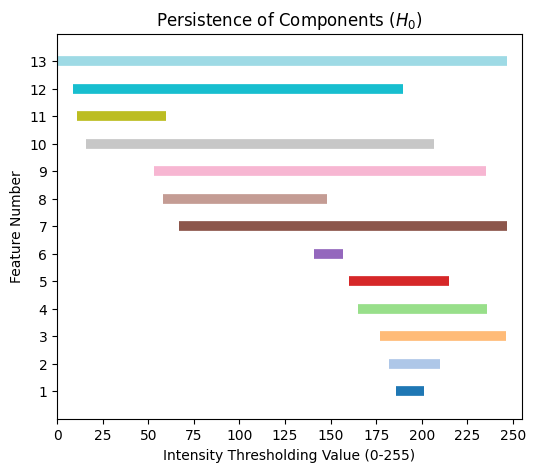

In [8]:
visualise_barcodes(filtered_persistence["dgms"][0],"Persistence of Components ($H_0$)",(6,5))

[np.float64(146.0), np.float64(46.0), np.float64(33.0)]


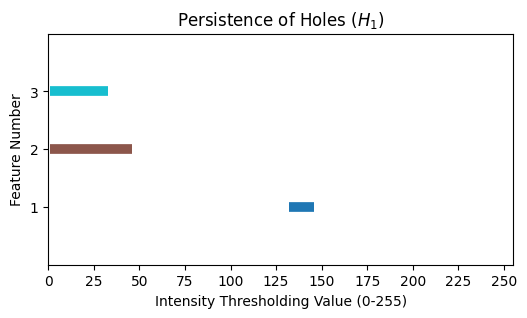

In [9]:
visualise_barcodes(filtered_persistence["dgms"][1][::-1],"Persistence of Holes ($H_1$)",(6,3))

In [29]:
def cycle_intensity(cycles):
    #cycle strength is cycle death time
    cycles = [i[1] for i in cycles]
    return cycles

def edge_strength(components,b1=5,b2=100,plot=False):
    #edge strength is component birth time
    edges = [i[0] for i in components]
    return edges

def component_intensity(components,d1=150,plot=False):
    #component intensity is component death time
    components = [i[1] for i in components]
    return components

def hole_strength(cycles):
    #hole strength is cycle birth time
    cycles = [i[0] for i in cycles]
    return cycles

In [30]:
components_intensities = component_intensity(components)
cycles_intensities = cycle_intensity(cycles)

edges_strengths = edge_strength(components)
holes_strengths = hole_strength(cycles)

Text(0, 0.5, 'Component Death Times')

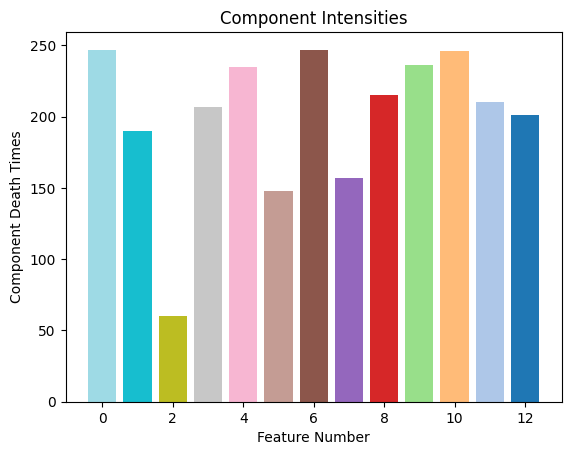

In [74]:
#component death times

line_colors = cm.tab20(np.linspace(0, 1, len(components_intensities)))

plt.bar(range(len(components_intensities)),components_intensities[::-1],color=line_colors[::-1])

plt.title("Component Intensities")
plt.xlabel("Feature Number")
plt.ylabel("Component Death Times")

Text(0, 0.5, 'Component Birth Times')

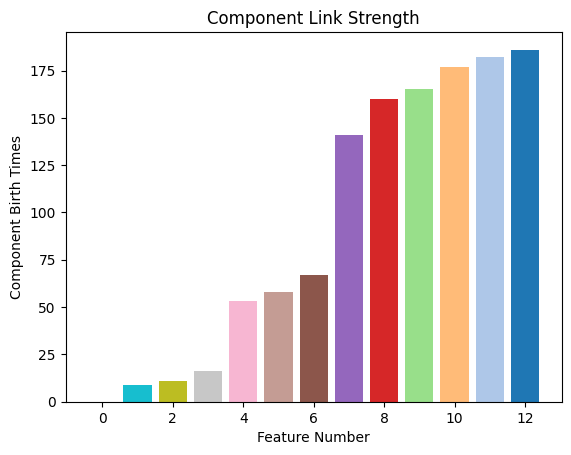

In [72]:
#component birth times

line_colors = cm.tab20(np.linspace(0, 1, len(components_intensities)))
plt.bar(range(len(edges_strengths)),edges_strengths[::-1],color=line_colors[::-1])

plt.title("Component Link Strength")
plt.xlabel("Feature Number")
plt.ylabel("Component Birth Times")

Text(0, 0.5, 'Hole Death Times')

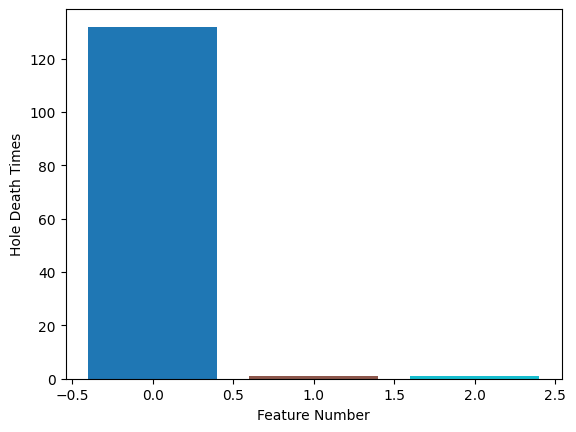

In [62]:
#cycle birth times

line_colors = cm.tab10(np.linspace(0, 1, len(holes_strengths)))


plt.bar(range(len(holes_strengths)),holes_strengths,color=line_colors)
plt.xlabel("Feature Number")
plt.ylabel("Hole Death Times")

Text(0, 0.5, 'Hole Death Times')

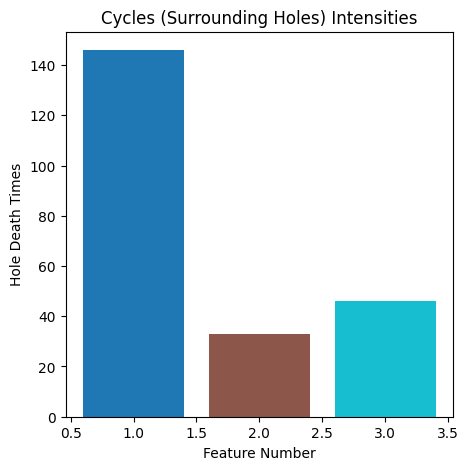

In [77]:
#cycle death times

line_colors = cm.tab10(np.linspace(0, 1, len(holes_strengths)))
fig,ax=plt.subplots(figsize=(5,5))

plt.bar([1,2,3],cycles_intensities,color=line_colors)
plt.title("Cycles (Surrounding Holes) Intensities")
plt.xlabel("Feature Number")
plt.ylabel("Hole Death Times")